In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

import itertools

from tqdm import tqdm

import pandas as pd

## Purpose
---
Classification of students as: Biologists, Bioinformaticians, Mathematicians, based on scores on Biology and Math exams (synthetic data)

## Data generation
---
Biology exam scope:
1. Animal taxonomy
2. Plant taxonomy
3. Biochemistry
4. Molecular biology
5. Genetics
6. Immunology
7. Ecology
8. Cell biology
9. Microbiology
10. Developmental biology

Math exam scope:
1. Abstract algebra
2. Linear algebra
3. Logic and set theory
4. Probability
5. Statistics
6. Differential equations
7. Real and Complex analysis
8. Topology
9. Measure theory
10. Discrete math

In [2]:
biologist_masks = {
    "biology": np.array([0.9, 0.8, 0.7, 0.8, 0.7, 
                         0.6, 0.8, 0.8, 0.7, 0.8]),
    "math": np.array([0.1, 0.1, 0.1, 0.5, 0.5, 
                      0.1, 0.1, 0.1, 0.1, 0.1])
}
mathematician_masks = {
    "biology": np.array([0.1, 0.1, 0.1, 0.1, 0.5, 
                         0.1, 0.5, 0.1, 0.1, 0.1]),
    "math": np.array([0.9, 0.8, 0.8, 0.8, 0.6, 
                      0.8, 0.8, 0.8, 0.8, 0.8])
}
bioinformatician_masks = {
    "biology": np.array([0.2, 0.2, 0.7, 0.7, 0.7, 
                         0.5, 0.3, 0.3, 0.3, 0.3]),
    "math": np.array([0.3, 0.6, 0.5, 0.6, 0.6, 
                      0.3, 0.3, 0.2, 0.2, 0.7])
}

In [36]:
Bbio, Bmath = [], []
Mbio, Mmath = [], []
BIbio, BImath = [], []

for i in range(4096):
    Bbio.append(np.sum(np.random.rand(10) <= biologist_masks["biology"]))
    Bmath.append(np.sum(np.random.rand(10) <= biologist_masks["math"]))

    Mbio.append(np.sum(np.random.rand(10) <= mathematician_masks["biology"]))
    Mmath.append(np.sum(np.random.rand(10) <= mathematician_masks["math"]))

    #BIbio.append(np.sum((np.random.rand(10) - np.random.lognormal()/5) <= bioinformatician_masks["biology"]))
    #BImath.append(np.sum((np.random.rand(10) - np.random.lognormal()/5) <= bioinformatician_masks["math"]))

    BIbio.append(np.sum(np.random.rand(10) <= bioinformatician_masks["biology"]) + 2)
    BImath.append(np.sum(np.random.rand(10) <= bioinformatician_masks["math"]) + 2)


tmp_list = []

for b, m in zip(Bbio, Bmath):
    tmp_list.append([b, m, "Biologist"])

for b, m in zip(Mbio, Mmath):
    tmp_list.append([b, m, "Mathematician"])

for b, m in zip(BIbio, BImath):
    tmp_list.append([b, m, "Bioinformatician"])

scores_df = pd.DataFrame(tmp_list, columns=["Biology", "Math", "Major"])

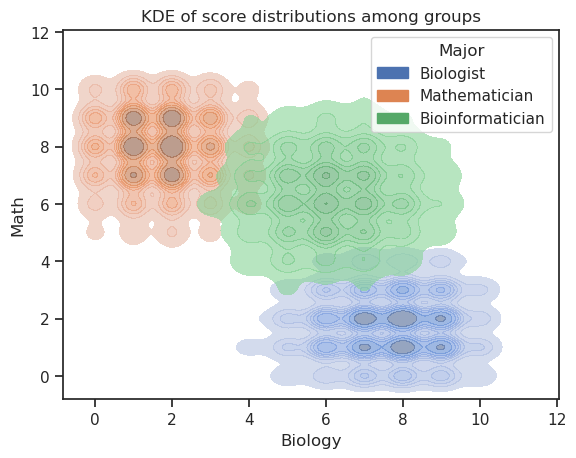

In [37]:
sns.set_theme(style="ticks")

p = sns.kdeplot(
    data=scores_df, 
    x="Biology", 
    y="Math", 
    hue="Major", 
    fill=True,
    alpha=0.6
)
plt.title("KDE of score distributions among groups")
plt.show()

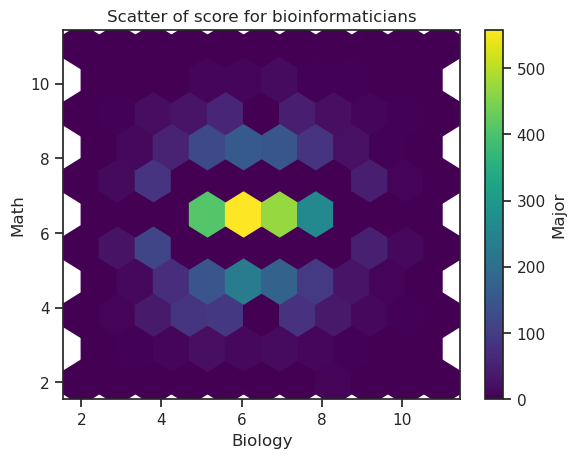

In [38]:
plt.hexbin(BIbio, BImath, gridsize=10, cmap="viridis")
plt.colorbar(label="Major")

plt.xlabel("Biology")
plt.ylabel("Math")

plt.title("Scatter of score for bioinformaticians")

plt.show()

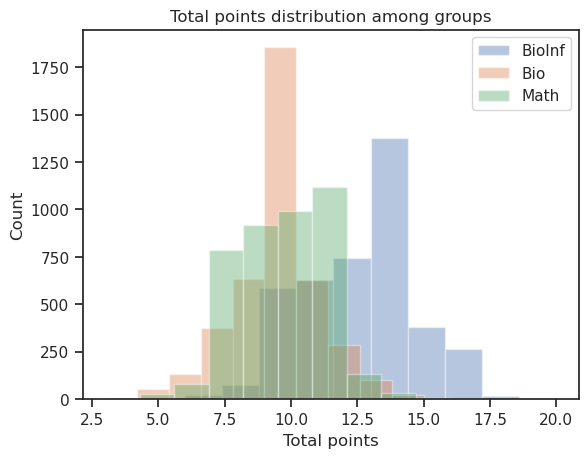

In [39]:
plt.hist(np.array(BIbio) + np.array(BImath), alpha=0.4)
plt.hist(np.array(Bbio) + np.array(Bmath), alpha=0.4)
plt.hist(np.array(Mbio) + np.array(Mmath), alpha=0.4)

plt.xlabel("Total points")
plt.ylabel("Count")

plt.title("Total points distribution among groups")
plt.legend(["BioInf", "Bio", "Math"])
plt.show()

## Encoding classes

In [40]:
df = scores_df[["Biology", "Math"]].copy()

one_hot = {
    "Biologist": [1, 0, 0],
    "Mathematician": [0, 1, 0],
    "Bioinformatician": [0, 0, 1]
}

one_hot_encoding = np.array([one_hot[k] for k in scores_df.Major])
df[["isBiologist", "isMathematician", "isBioinformatician"]] = one_hot_encoding

In [41]:
df

,Biology,Math,isBiologist,isMathematician,isBioinformatician
0,8,2,1,0,0
1,6,1,1,0,0
2,6,2,1,0,0
3,8,3,1,0,0
4,9,2,1,0,0
...,...,...,...,...,...
12283,6,7,0,0,1
12284,6,8,0,0,1
12285,3,5,0,0,1
12286,7,10,0,0,1


In [42]:
tmp = np.random.rand(len(df)) < 0.8
training_sele = np.where(tmp)
testing_sele = np.where(~tmp)
del tmp

In [43]:
X_train = np.array(df.iloc[training_sele][["Biology", "Math"]])
y_train = np.array(df.iloc[training_sele][["isBiologist", "isMathematician", "isBioinformatician"]])

X_test = np.array(df.iloc[testing_sele][["Biology", "Math"]])
y_test = np.array(df.iloc[testing_sele][["isBiologist", "isMathematician", "isBioinformatician"]])

### NN diagram
---
![](nn_diagram.png)

In [44]:
class NeuralNet:
    def init_params(self, layer_widths):
        """ From JAX pytree docs, initializees parameter values """
        params = []
        for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
            params.append(
                dict(weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2/n_in),
                     biases=np.ones(shape=(n_out,)))
            )
        return params

    def forward(self, params, x):
        """ Forward pass, from JAX pytree docs """
        *hidden, last = params

        for layer in hidden:
            x = jax.nn.relu(x @ layer['weights'] + layer['biases'])

        output = self.out_fn(x @ last['weights'] + last['biases'])

        return output

    def loss_fn(self, params, x, y):
        """ CCE """
        loss = -jnp.sum(y * jnp.log(self.forward(params, x)))
        self.loss_.append(loss)

        return loss

    #@jax.jit(static_argnames=["self", "params", "loss_fn", "learning_rate"])
    def update(self, params, x, y, loss_fn, learning_rate):
        """ Update parameter values based on loss function gradient """
        grads = jax.grad(loss_fn)(params, x, y)
        
        return jax.tree.map(
            lambda p, g: p - learning_rate * g, params, grads
        )

    def __init__(self, X, y, LEARNING_RATE, out_fn, layer_widths, batch=64):
        self.X_, self.y_ = X, y
        self.data_size_ = len(y)

        self.LEARNING_RATE = LEARNING_RATE
        self.out_fn = out_fn
        self.params = self.init_params(layer_widths)

        self.loss_ = []
        self.batch = batch

    def _epoch(self):
        """ Private method that runs single epoch """
        idxs = np.random.choice(range(self.data_size_), size=self.batch, replace=False)
        X, y = self.X_[idxs], self.y_[idxs]

        self.params = self.update(self.params, 
                                  X, y, 
                                  self.loss_fn, 
                                  self.LEARNING_RATE)

    def epochs(self, n=10):
        """ Run multiple epochs """
        for _ in tqdm(range(n)):
            self._epoch()

    def predict(self, x):
        return self.forward(self.params, x)

Making `LEARNING_RATE` larger than roughly 1e-6 leads to `NaNs` in output

In [52]:
nn = NeuralNet(
    X=X_train, y=y_train,
    LEARNING_RATE=1e-6,
    out_fn=jax.nn.softmax,
    layer_widths=[2, 4, 3, 3],
    batch=64
)

In [53]:
nn.epochs(n=1000)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 108.40it/s]


In [54]:
y_pred = jnp.argmax(nn.predict(X_test), axis=1)

In [55]:
print(f"Fraction of correct hits: "
      f"{jnp.sum(y_pred == jnp.argmax(y_test, axis=1)) / y_pred.shape[0]:.4f}")

Fraction of correct hits: 0.3313


In [56]:
def plot_regions():
    cmap = ListedColormap(["green", "blue", "red"])

    plt.scatter(all_combs.transpose()[0], 
                all_combs.transpose()[1], 
                c=preds, cmap=cmap)

    plt.title("Separation between classes")
    plt.show()

In [57]:
# Predict class for all score combinations
all_combs = jnp.array([*itertools.product(range(11), repeat=2)])
preds = jnp.argmax(nn.predict(all_combs), axis=1)
true = jnp.argmax(y_test, axis=1)

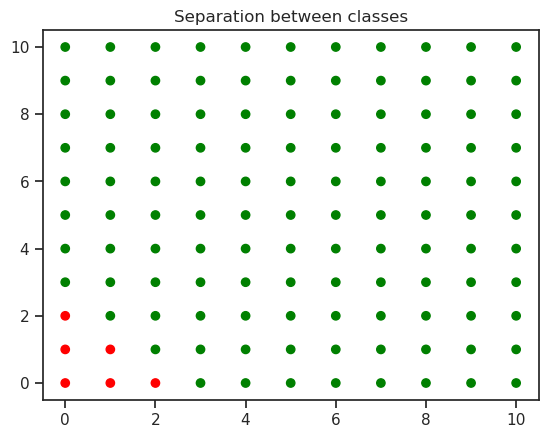

In [58]:
cmap = ListedColormap(["green", "blue", "red"])

plt.scatter(all_combs.transpose()[0], 
            all_combs.transpose()[1], 
            c=preds, cmap=cmap)

plt.title("Separation between classes")
plt.show()

## Classifying circular areas against background

In [1189]:
def select_area(M, x, center, radius):
    """ M is 2×2, x is 2×1, ori is  """
    return jnp.linalg.norm(M @ x - center) < radius

batch_select_area = jax.vmap(
    select_area,
    in_axes=(None, 0, None, None)
)
hyper_batch_select_area = jax.vmap(
    batch_select_area,
    in_axes=(0, None, 0, None)
)

In [1242]:
scaling = np.array([[10, 0], [0, 10]])
move = np.array([-5, -5])

X_ = np.random.rand(2, 2048)
X_ = (scaling @ X_).transpose() + move

In [1243]:
Ms = [np.array([[1, 0], [0, 1]])]
centers = [np.array([0, 0])]

In [1244]:
for _ in range(64):
    Ms.append(jnp.array(np.random.rand(2, 2)) * 0.5)
    centers.append(jnp.array(X_[np.random.choice(range(len(X_)))]))

In [1245]:
Ms = jnp.array(Ms)
centers = jnp.array(centers)

In [1246]:
sele = np.any(hyper_batch_select_area(Ms, X_, centers, 0.8), axis=0)

In [1247]:
sele = X_.transpose()[0] * X_.transpose()[1] > 0

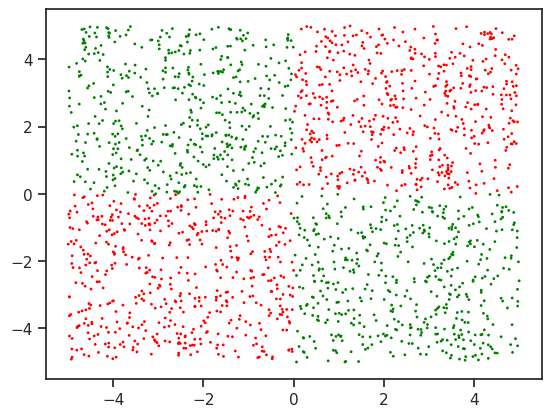

In [1248]:
plt.scatter(*X_.transpose(), 
            s=1,
            cmap=ListedColormap(["green", "red"]),
            c=sele)
plt.show()

In [1442]:
new_nn = NeuralNet(
    X=X_, y=sele,
    LEARNING_RATE=1e-8,
    out_fn=jax.nn.sigmoid,
    layer_widths=[2, 4, 4, 4, 1],
    batch=128
)

In [1451]:
new_nn.epochs(n=512)

100%|█████████████████████████████████████████████████████████████████████████████████| 512/512 [00:05<00:00, 89.57it/s]


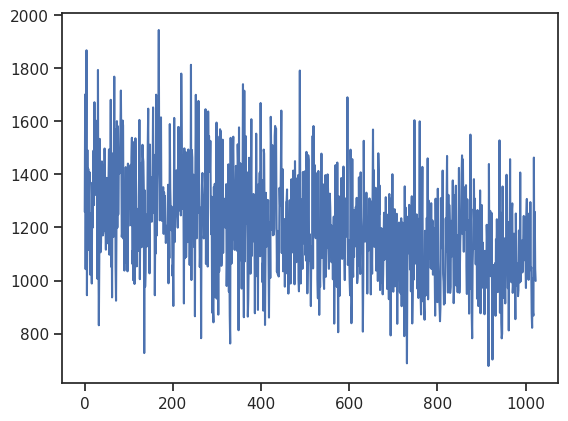

In [1452]:
plt.plot(np.array([*map(lambda x: x.primal, new_nn.loss_)]) + 1)
plt.show()

In [1453]:
x, y = jnp.linspace(-10, 10, 100), jnp.linspace(-10, 10, 100)
points = jnp.stack(
    jnp.meshgrid(x, y, indexing="xy"),
    axis=-1
).reshape(-1, 2)

In [1454]:
#verif_sele = np.any(hyper_batch_select_area(Ms, points, centers, 0.05), axis=0)

In [1455]:
pred_sele = new_nn.predict(points).reshape(10000,)

In [1456]:
verify_sele = points.transpose()[0] * points.transpose()[1] > 0

In [1457]:
pred_sele, verify_sele.shape

(Array([0.9360799 , 0.930869  , 0.92526716, ..., 1.        , 1.        ,
        1.        ], dtype=float32),
 (10000,))

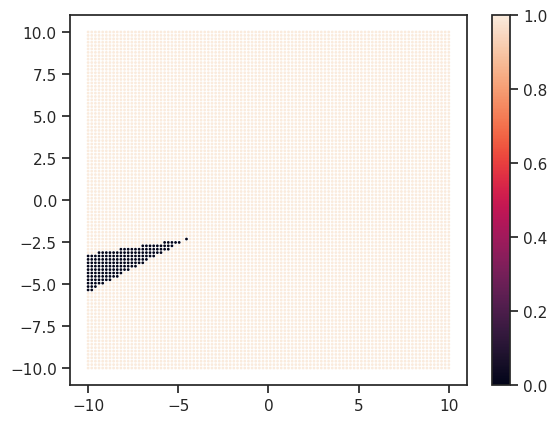

In [1458]:
plt.scatter(*points.transpose(), s=1, c=pred_sele > 0.5, vmin=0, vmax=1)
#plt.scatter(*points.transpose(), s=1, c=verify_sele, vmin=0, vmax=1)

plt.colorbar()
plt.show()

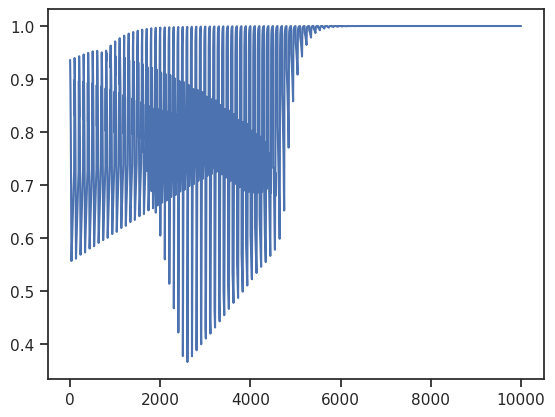

In [1459]:
plt.plot(pred_sele)
plt.show()

In [1460]:
np.sum((pred_sele.reshape(10000,) > 0.5) == verify_sele) / len(verif_sele)

Array(48.39, dtype=float32)